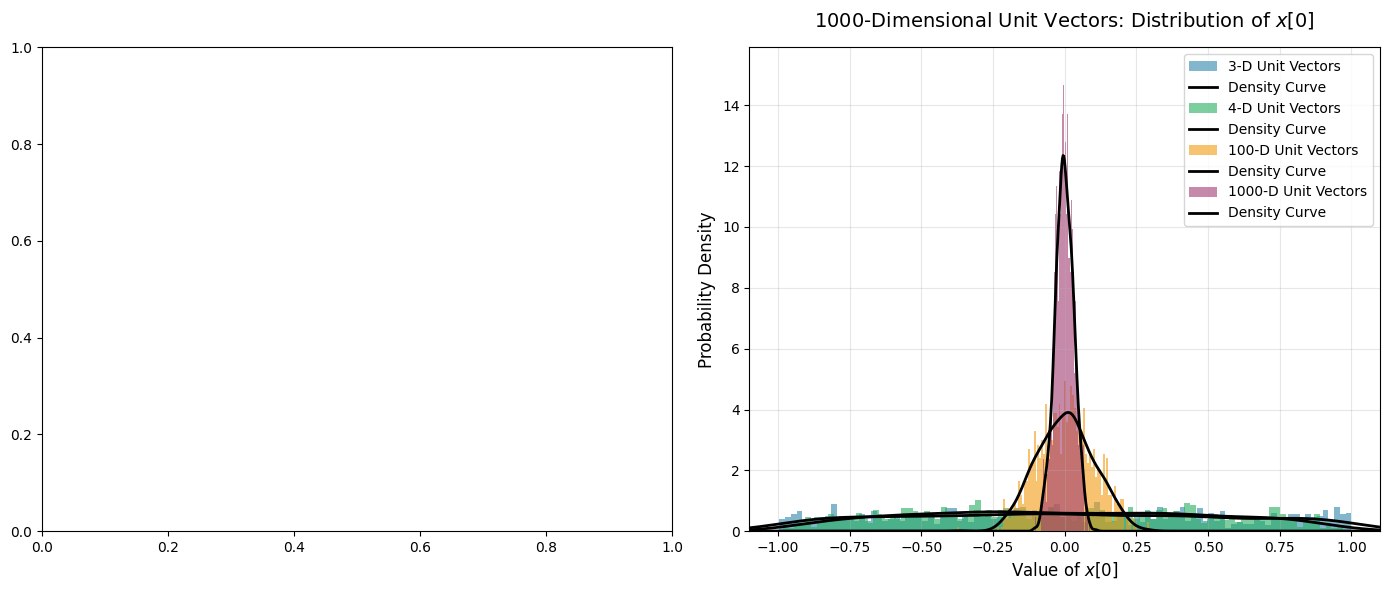

=== 第一个坐标（x[0]）的统计信息 ===
3维:
  均值: -0.000706 (接近0，符合对称性)
  标准差: 0.566998 (高维更小，更集中)
  99%样本范围: [-0.978398, 0.995800] (高维区间更窄)

4维:
  均值: -0.010529 (接近0，符合对称性)
  标准差: 0.503412 (高维更小，更集中)
  99%样本范围: [-0.955546, 0.946347] (高维区间更窄)

100维:
  均值: 0.003049 (接近0，符合对称性)
  标准差: 0.099002 (高维更小，更集中)
  99%样本范围: [-0.214592, 0.245267] (高维区间更窄)

1000维:
  均值: -0.000814 (接近0，符合对称性)
  标准差: 0.032112 (高维更小，更集中)
  99%样本范围: [-0.081847, 0.078037] (高维区间更窄)



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde  # 用于绘制平滑的概率密度曲线

# ---------------------- 1. 生成单位球面上的随机向量 ----------------------
def generate_unit_sphere_vectors(dim, num_samples):
    """
    生成均匀分布在 d 维单位球面上的随机向量
    方法：先生成标准正态分布向量，再归一化（保证均匀性）
    """
    # 生成 dim 维、num_samples 个样本的标准正态分布矩阵（均值0，方差1）
    random_vectors = np.random.normal(loc=0.0, scale=1.0, size=(num_samples, dim))
    
    # 计算每个向量的 L2 范数（长度）
    norms = np.linalg.norm(random_vectors, axis=1, keepdims=True)
    
    # 归一化：每个向量除以自身长度，得到单位向量（落在单位球面上）
    unit_vectors = random_vectors / norms
    
    return unit_vectors

# 配置参数：样本数量（越多分布越平滑）、两个对比维度
num_samples = 1000  # 10万个样本，保证统计显著性
dimensions = [3, 4, 100, 1000]  # 3维 vs 1000维

# 生成两个维度的单位向量，并提取第一个坐标（x[0]）
x0_samples = {}
for dim in dimensions:
    unit_vecs = generate_unit_sphere_vectors(dim, num_samples)
    x0_samples[dim] = unit_vecs[:, 0]  # 取所有样本的第0个坐标


# ---------------------- 2. 可视化分布对比 ----------------------
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 支持英文显示
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # 1行2列子图

# 定义颜色（区分两个维度）
colors = {3: '#2E86AB', 4: '#27AE60', 100: '#F39C12', 1000: '#A23B72'}

# 遍历两个维度，绘制直方图+密度曲线
for idx, dim in enumerate(dimensions):
    ax = ax1 if idx == 0 else ax2
    ax = ax2
    samples = x0_samples[dim]
    
    # 1. 绘制直方图（ bins 控制分箱数，密度归一化）
    ax.hist(
        samples, 
        bins=100, 
        density=True, 
        alpha=0.6,  # 透明度
        color=colors[dim], 
        label=f'{dim}-D Unit Vectors'
    )
    
    # 2. 绘制平滑的概率密度曲线（用KDE估计）
    kde = gaussian_kde(samples)
    x_range = np.linspace(-1.1, 1.1, 1000)  # 横轴范围
    ax.plot(
        x_range, 
        kde(x_range), 
        color='black', 
        linewidth=2, 
        label='Density Curve'
    )
    
    # 3. 标注关键信息
    ax.set_title(f'{dim}-Dimensional Unit Vectors: Distribution of $x[0]$', fontsize=14, pad=15)
    ax.set_xlabel('Value of $x[0]$', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_xlim(-1.1, 1.1)  # 固定x轴范围，便于对比
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)  # 网格线（增强可读性）

# 调整子图间距
plt.tight_layout()

# 保存图片（可选，高清格式）
plt.savefig('unit_vector_x0_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------- 3. 输出统计信息（验证高维集中性） ----------------------
print("=== 第一个坐标（x[0]）的统计信息 ===")
for dim in dimensions:
    samples = x0_samples[dim]
    mean = np.mean(samples)
    std = np.std(samples)
    # 计算 99% 样本的分布范围（体现集中程度）
    p005 = np.percentile(samples, 0.5)
    p995 = np.percentile(samples, 99.5)
    print(f"{dim}维:")
    print(f"  均值: {mean:.6f} (接近0，符合对称性)")
    print(f"  标准差: {std:.6f} (高维更小，更集中)")
    print(f"  99%样本范围: [{p005:.6f}, {p995:.6f}] (高维区间更窄)")
    print()